In [1]:
from scipy.stats import mannwhitneyu
import warnings
import torch
import pandas as pd
import numpy as np
from PIL import Image
from glob import glob
from sewar import msssim
import json
from torchvision import transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ultralytics import YOLO


from _analysis_functions import (
    get_mimicry_data,
    cohens_d,
    plot_compare_metric,
)

plt.rc("font", size=14)
plt.rc("text", usetex=False)
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [2]:
dataset_names = [r"CelebA-glasses", r"CelebA-gender", r"COCO", r"Dogs"]

### Preprocess Data if not already available as csv.
If the data is available scroll down.

In [17]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def load_rexnet_dog_classifier(ckpt_path, device):
    import timm

    model_name = "rexnet_150"
    num_classes = 78
    model = timm.create_model(model_name=model_name, num_classes=num_classes)
    model = model.to(device)
    model.load_state_dict(torch.load(ckpt_path))
    model.eval()
    return model


def get_distance(row, tpe="d2"):
    img_path = row["img_path"]
    original_path = "/".join(img_path.split("/")[:-1]) + "/1_original.png"
    im, orig_im = Image.open(img_path), Image.open(original_path)
    im, orig_im = np.array(im) / 255.0, np.array(orig_im) / 255.0

    if tpe == "d2":
        max_d = np.linalg.norm(np.ones_like(im))
        distance = np.linalg.norm(orig_im - im) / max_d
    elif tpe == "ssim":
        distance = msssim(orig_im, im, MAX=1.0)
    return distance


transform = transforms.Compose([transforms.ToTensor()])


def get_pred(row, model):
    img_path = row["img_path"]
    original_path = "/".join(img_path.split("/")[:-1]) + "/1_original.png"
    im, orig_im = transform(Image.open(img_path)), transform(Image.open(original_path))
    with torch.no_grad():
        pred_orig = model(orig_im.unsqueeze(0).cuda())
        pred = model(im.unsqueeze(0).cuda())
    return pred_orig, pred


def get_df_from_files(files: list[str]) -> pd.DataFrame:
    df = []
    for f in files:
        with open(f, "r") as fp:
            data = json.load(fp)
        df.append(pd.DataFrame([data]))
    df = pd.concat(df)
    return df


def df_apply_distances(df: pd.DataFrame) -> pd.DataFrame:
    df["distance"] = df.apply(lambda row: get_distance(row, "d2"), axis=1)
    df["ssim"] = df.apply(lambda row: get_distance(row, "ssim"), axis=1)
    return df

In [ ]:
faces_dir = "/home/weissl/Projects/xc/runs/small_smoothgrad_misclassification/15_Eyeglasses"
faces_male_dir = "/home/weissl/Projects/xc/runs/small_smoothgrad_misclassification/20_Male"
cars_dir = "/home/weissl/Projects/xc/runs/cars_small_smoothgrad_misclassification"
dogs_dir = "/home/weissl/Projects/xc/runs/dogs_smoothgrad_misclassification"

In [ ]:
faces_all = glob(faces_dir + "/*/*.json")
num_with_fail = len(set([f.split("/")[-2] for f in faces_all]))
print(f"Numbers of seeds with failures found: {num_with_fail}")
print(f"Numbers of failures found: {len(faces_all)}")
print(f"Factor: {len(faces_all)/num_with_fail}")

In [ ]:
faces_male_all = glob(faces_male_dir + "/*/*.json")
num_with_fail = len(set([f.split("/")[-2] for f in faces_male_all]))
print(f"Numbers of seeds with failures found: {num_with_fail}")
print(f"Numbers of failures found: {len(faces_male_all)}")
print(f"Factor: {len(faces_male_all)/num_with_fail}")

In [ ]:
cars_all = glob(cars_dir + "/*/*.json")
num_with_fail = len(set([f.split("/")[-2] for f in cars_all]))
print(f"Numbers of seeds with failures found: {num_with_fail}")
print(f"Numbers of failures found: {len(cars_all )}")
print(f"Factor: {len(cars_all)/num_with_fail}")

In [ ]:
dogs_all = glob(dogs_dir + "/**/*/*.json")
num_with_fail = len(set([f.split("/")[-2] for f in dogs_all]))
print(f"Numbers of seeds with failures found: {num_with_fail}")
print(f"Numbers of failures found: {len(dogs_all )}")
print(f"Factor: {len(dogs_all)/num_with_fail}")

In [ ]:
df = get_df_from_files(faces_all)
df = df_apply_distances(df)

In [ ]:
df_male = get_df_from_files(faces_male_all)
df_male = df_apply_distances(df_male)

In [ ]:
cars_df = get_df_from_files(cars_all)
cars_df = df_apply_distances(cars_df)

In [ ]:
dogs_df = get_df_from_files(dogs_all)
dogs_df = df_apply_distances(dogs_df)

In [22]:
sut_path_dog = "/home/weissl/Projects/xc/local_models/classifiers/checkpoints/dogs_triplet_rexnet_150_best_model.pth"
model = load_rexnet_dog_classifier(sut_path_dog, torch.device("cuda"))
model.eval()

dogs_df[["pred_orig", "pred"]] = dogs_df.apply(
    lambda row: get_pred(row, model), axis=1, result_type="expand"
)
dogs_df["pred_orig"] = dogs_df["pred_orig"].apply(lambda x: x.squeeze().cpu())
dogs_df["pred"] = dogs_df["pred"].apply(lambda x: x.squeeze().cpu())
dogs_df["pred_orig"] = dogs_df["pred_orig"].apply(lambda x: F.softmax(x, dim=-1).numpy())
dogs_df["pred"] = dogs_df["pred"].apply(lambda x: F.softmax(x, dim=-1).numpy())

In [23]:
yolo = YOLO("yolov8n.pt")
model = yolo.model.to(torch.device("cuda"))
model.eval()

results = dogs_df.apply(lambda row: get_pred(row, model), axis=1, result_type="expand")
cars_df[["pred_orig", "pred"]] = results.reset_index(drop=True)
cars_df["pred_orig"] = cars_df["pred_orig"].apply(lambda x: x[0].squeeze().T[:, 4:].cpu())
cars_df["pred"] = cars_df["pred"].apply(lambda x: x[0].squeeze().T[:, 4:].cpu())
cars_df["pred_orig"] = cars_df["pred_orig"].apply(lambda x: x[x.max(axis=1).values.argmax().item()])
cars_df["pred"] = cars_df["pred"].apply(lambda x: x[x.max(axis=1).values.argmax().item()])
cars_df["pred"] = cars_df["pred"].apply(lambda x: x.numpy())
cars_df["pred_orig"] = cars_df["pred_orig"].apply(lambda x: x.numpy())

In [53]:
df.to_csv("detect_faces.csv")
df_male.to_csv("detect_faces_male.csv")
cars_df.to_csv("detect_cars.csv")
dogs_df.to_csv("detect_dogs.csv")

### Load Data if available as .csv

In [3]:
mimicry_faces_data = get_mimicry_data("faces_glasses")
mimicry_faces_data_male = get_mimicry_data("faces_male")
mimicry_cars_data = get_mimicry_data("cars")
mimicry_dogs_data = get_mimicry_data("dogs")

Found 43 SMOO directories
Found 50 SMOO directories
Found 50 SMOO directories
Found 50 SMOO directories


In [4]:
df = pd.read_csv("detect_faces.csv")
df_male = pd.read_csv("detect_faces_male.csv")
cars_df = pd.read_csv("detect_cars.csv")
dogs_df = pd.read_csv("detect_dogs.csv")

In [5]:
glasses_relevant = [
    "b8_conv0_affine_228",
    "b8_conv0_affine_97",
    "b16_conv0_affine_325",
    "b8_conv0_affine_175",
]
male_relevant = [
    "b32_conv1_affine_6",
    "b32_conv1_affine_421",
    "b256_conv0_affine_101",
    "b512_conv0_affine_55",
]

In [6]:
glasses_relevant_df = df[
    df["img_path"].apply(lambda x: any(m in x for m in glasses_relevant)) == True
]
male_relevant_df = df_male[
    df_male["img_path"].apply(lambda x: any(m in x for m in male_relevant)) == True
]

### Check Runtime


Mean: 1.256, Std: 0.384
Mean: 3.846, Std: 2.830
Mean: 3.247, Std: 2.208
Mean: 3.697, Std: 2.423
Mean: 1.277, Std: 0.354
Mean: 1.232, Std: 0.832
Mean: 96.795, Std: 0.751
Mean: 96.342, Std: 0.676
Mean: 50.982, Std: 0.702
Mean: 12.325, Std: 0.674


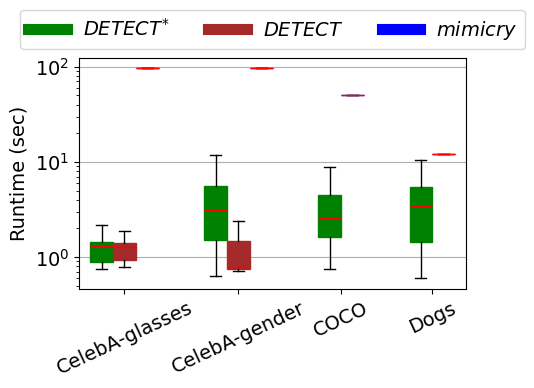

In [30]:
xc_data = [
    df["runtime"].tolist(),
    df_male["runtime"].tolist(),
    cars_df["runtime"].tolist(),
    dogs_df["runtime"].tolist(),
]
xc_relevant = [glasses_relevant_df["runtime"].tolist(), male_relevant_df["runtime"].tolist()]
mimicry_data = [
    mimicry_faces_data["runtime"].tolist(),
    mimicry_faces_data_male["runtime"],
    mimicry_cars_data["runtime"].tolist(),
    mimicry_dogs_data["runtime"].tolist(),
]
plot_compare_metric(
    xc_data,
    xc_relevant,
    mimicry_data,
    exp_labels=["$DETECT^{*}$", "$DETECT$", "$mimicry$"],
    tick_labels=dataset_names,
    name="Runtime (sec)",
    log=True,
    save_as="figures/RQ2/runtime",
    figsize=(5, 3),
)
for df_list in [xc_data, xc_relevant, mimicry_data]:
    print("=" * 40)
    for elem in df_list:
        print(f"Mean: {np.mean(elem):.3f}, Std: {np.std(elem):.3f}")

### Check Image Change

Mean: 0.088, Std: 0.043
Mean: 0.115, Std: 0.083
Mean: 0.094, Std: 0.045
Mean: 0.073, Std: 0.043
Mean: 0.084, Std: 0.025
Mean: 0.098, Std: 0.025
Mean: 0.250, Std: 0.049
Mean: 0.247, Std: 0.046
Mean: 0.251, Std: 0.044
Mean: 0.281, Std: 0.065


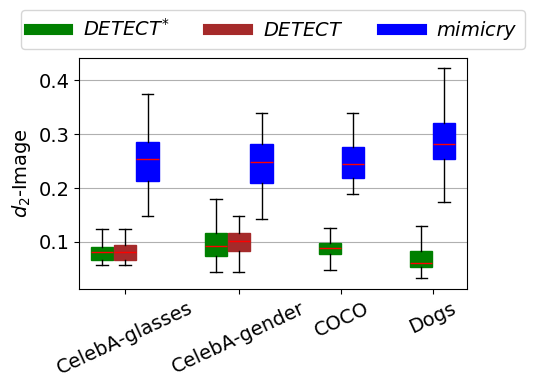

In [31]:
xc_data = [
    df["distance"].tolist(),
    df_male["distance"],
    cars_df["distance"].tolist(),
    dogs_df["distance"].tolist(),
]
xc_relevant = [glasses_relevant_df["distance"].tolist(), male_relevant_df["distance"].tolist()]
mimicry_data = [
    mimicry_faces_data["distance"].tolist(),
    mimicry_faces_data_male["distance"],
    mimicry_cars_data["distance"].tolist(),
    mimicry_dogs_data["distance"],
]
plot_compare_metric(
    xc_data,
    xc_relevant,
    mimicry_data,
    exp_labels=["$DETECT^{*}$", "$DETECT$", "$mimicry$"],
    tick_labels=dataset_names,
    name="$d_2$-Image",
    log=False,
    save_as="figures/RQ2/dist",
    figsize=(5, 3),
)

for df_list in [xc_data, xc_relevant, mimicry_data]:
    print("=" * 40)
    for elem in df_list:
        print(f"Mean: {np.mean(elem):.3f}, Std: {np.std(elem):.3f}")

Mean: 0.732, Std: 0.053
Mean: 0.714, Std: 0.087
Mean: 0.759, Std: 0.072
Mean: 0.819, Std: 0.100
Mean: 0.730, Std: 0.054
Mean: 0.668, Std: 0.090
Mean: 0.420, Std: 0.073
Mean: 0.415, Std: 0.065
Mean: 0.332, Std: 0.083
Mean: 0.157, Std: 0.134


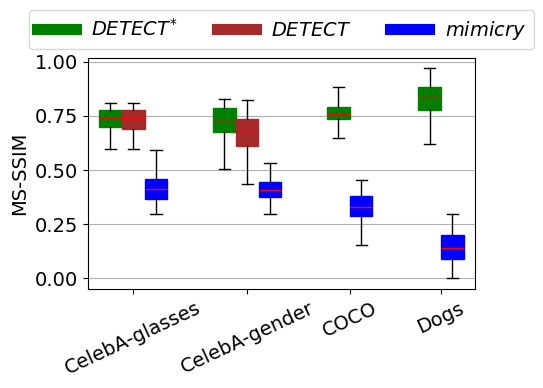

In [32]:
xc_data = [
    df["ssim"].apply(lambda x: complex(x).real).tolist(),
    df_male["ssim"].apply(lambda x: complex(x).real).tolist(),
    cars_df["ssim"].apply(lambda x: complex(x).real).tolist(),
    dogs_df["ssim"].apply(lambda x: complex(x).real).tolist(),
]
xc_relevant = [
    glasses_relevant_df["ssim"].apply(lambda x: complex(x).real).tolist(),
    male_relevant_df["ssim"].apply(lambda x: complex(x).real).tolist(),
]
mimicry_data = [
    mimicry_faces_data["ssim"].tolist(),
    mimicry_faces_data_male["ssim"].tolist(),
    mimicry_cars_data["ssim"].tolist(),
    mimicry_dogs_data["ssim"].tolist(),
]
plot_compare_metric(
    xc_data,
    xc_relevant,
    mimicry_data,
    exp_labels=["$DETECT^{*}$", "$DETECT$", "$mimicry$"],
    tick_labels=dataset_names,
    name="MS-SSIM",
    log=False,
    save_as="figures/RQ2/ssim",
    figsize=(5, 3),
)

for df_list in [xc_data, xc_relevant, mimicry_data]:
    print("=" * 40)
    for elem in df_list:
        print(f"Mean: {np.mean(elem):.3f}, Std: {np.std(elem):.3f}")

### Effect on Predictions


In [33]:
for md, elem_idx in zip(
    [mimicry_dogs_data, mimicry_cars_data, mimicry_faces_data, mimicry_faces_data_male],
    [-1, 2, 15, 20],
):
    md["w0_predictions"] = md["w0_predictions"].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=" ") if isinstance(x, str) else x
    )
    md["best_0_y_hat"] = md["best_0_y_hat"].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=" ") if isinstance(x, str) else x
    )

    if elem_idx > -1:
        md["change"] = md["w0_predictions"].apply(lambda x: x[elem_idx]) - md["best_0_y_hat"].apply(
            lambda x: x[elem_idx]
        )

In [34]:
mimicry_dogs_orig, mimicry_dogs_target = mimicry_dogs_data["w0_predictions"].apply(
    np.max
), mimicry_dogs_data.apply(
    lambda row: row["best_0_y_hat"][np.argmax(row["w0_predictions"])], axis=1
)
mimicry_dogs_data["change"] = mimicry_dogs_orig - mimicry_dogs_target

In [35]:
df["change"] = df["confidence_drop"]
df_male["change"] = df_male["confidence_drop"]
cars_df["change"] = cars_df["original_confidence"].apply(sigmoid) - cars_df[
    "perturbed_confidence"
].apply(sigmoid)

glasses_relevant_df["change"] = glasses_relevant_df["confidence_drop"]
male_relevant_df["change"] = male_relevant_df["confidence_drop"]

In [36]:
dogs_df["pred_orig"], dogs_df["pred"] = dogs_df["pred_orig"].apply(
    lambda x: np.fromstring(x.strip("[]"), sep=" ") if isinstance(x, str) else x
), dogs_df["pred"].apply(
    lambda x: np.fromstring(x.strip("[]"), sep=" ") if isinstance(x, str) else x
)
dogs_df["change"] = dogs_df["pred_orig"].apply(np.max) - dogs_df.apply(
    lambda row: row["pred"][np.argmax(row["pred_orig"])], axis=1
)

In [37]:
def plot_on_axis(
    *experiments, exp_labels: list[str], tick_labels: list[str], name: str, log: bool = False, ax
):
    max_len = max([len(e) for e in experiments])
    positions = [[] for _ in range(len(experiments))]
    middle = []

    prev_base, base = 1, 1
    for i in range(max_len):
        for j, exp in enumerate(experiments):
            if len(exp) > i:
                positions[j].append(base)
                base += 0.5
        middle.append((prev_base + base) / 2 - 0.25)
        base, prev_base = base + 1, base + 1

    boxpl_args = dict(widths=0.495, patch_artist=True, medianprops=dict(color="red"))

    for i, exp in enumerate(experiments):
        if all(len(e) == 0 for e in exp):
            positions[i + 1 : -1] = positions[i:-1]
            continue
        ax.boxplot(
            exp,
            positions=positions[i],
            boxprops=dict(facecolor=colors[i], color=colors[i]),
            showfliers=False,
            **boxpl_args,
        )
        ax.plot([], color=colors[i], label=exp_labels[i], linewidth=8)

    ax.set_ylabel(name)
    ax.set_xticks(middle)
    ax.set_xticklabels(tick_labels, rotation=25)
    if log:
        ax.set_yscale("log")
    ax.grid(axis="y")

Mean: 5.092, Std: 2.165
Mean: 1.871, Std: 2.104
Mean: 0.182, Std: 0.090
Mean: 0.121, Std: 0.248
Mean: 5.044, Std: 2.204
Mean: 5.603, Std: 2.959
Mean: 0.815, Std: 0.528
Mean: 0.099, Std: 0.758
Mean: 0.351, Std: 0.233
Mean: 0.269, Std: 0.239


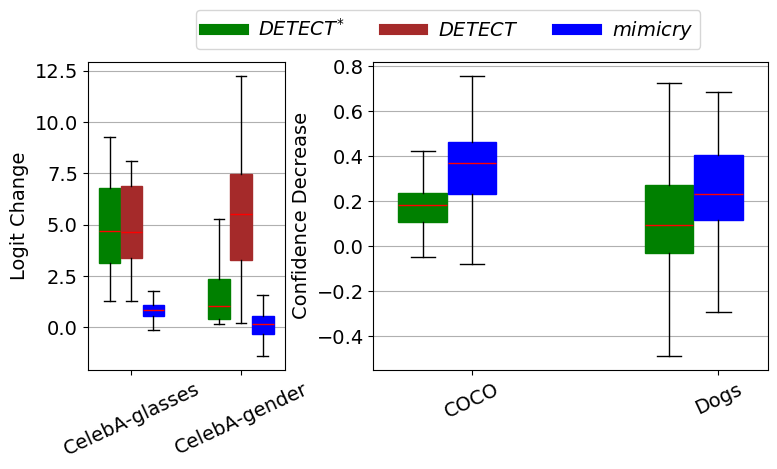

In [39]:
colors = ["green", "brown", "blue"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={"width_ratios": [1, 2]})

plot_on_axis(
    [df["change"], df_male["change"]],
    [glasses_relevant_df["change"], male_relevant_df["change"]],
    [mimicry_faces_data["change"], mimicry_faces_data_male["change"]],
    exp_labels=["$DETECT^{*}$", "$DETECT$", "$mimicry$"],
    tick_labels=["CelebA-glasses", "CelebA-gender"],
    name="Logit Change",
    log=False,
    ax=ax1,
)

plot_on_axis(
    [cars_df["change"], dogs_df["change"]],
    [[], []],
    [mimicry_cars_data["change"], mimicry_dogs_data["change"]],
    exp_labels=["$DETECT^{*}$", "$DETECT$", "$mimicry$"],
    tick_labels=["COCO", "Dogs"],
    name="Confidence Decrease",
    log=False,
    ax=ax2,
)

ax1.legend(loc="upper left", bbox_to_anchor=(0.5, 1.20), ncol=3)
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.savefig("figures/RQ2/sut_change.pdf", bbox_inches="tight")


for df_list in [
    [df["change"], df_male["change"], cars_df["change"], dogs_df["change"]],
    [glasses_relevant_df["change"], male_relevant_df["change"]],
    [
        mimicry_faces_data["change"],
        mimicry_faces_data_male["change"],
        mimicry_cars_data["change"],
        mimicry_dogs_data["change"],
    ],
]:
    print("=" * 40)
    for elem in df_list:
        print(f"Mean: {np.mean(elem):.3f}, Std: {np.std(elem):.3f}")

### Analyse Boundary Stats

In [40]:
for md, idx in zip([mimicry_faces_data, mimicry_faces_data_male], [15, 20]):
    md["boundary_distance"] = md["best_0_y_hat"].apply(lambda x: abs(x[idx]))

for md in [mimicry_dogs_data, mimicry_cars_data]:
    original_class = md["w0_predictions"].apply(np.argmax)
    boundary = np.stack(md["best_0_y_hat"].apply(lambda x: np.argsort(x)[::-1][:2]).to_numpy())
    b = np.stack(md["best_0_y_hat"].apply(lambda x: np.zeros_like(x)).to_numpy())

    pred = np.stack(md["best_0_y_hat"].to_numpy())
    for i, bounds in enumerate(boundary):
        b[i, bounds] = 0.5

    md["boundary_distance"] = np.linalg.norm(pred - b, axis=1)
    md["escaped"] = [orig not in top2 for orig, top2 in zip(original_class, boundary)]

In [41]:
for dd in [df, df_male, glasses_relevant_df, male_relevant_df]:
    dd["boundary_distance"] = dd["prediction_perturbed_target"].apply(abs)

for dd in [cars_df, dogs_df]:
    original_class = dd["pred_orig"].apply(np.argmax)
    boundary = np.stack(dd["pred"].apply(lambda x: np.argsort(x)[::-1][:2]).to_numpy())
    b = np.stack(dd["pred"].apply(lambda x: np.zeros_like(x)).to_numpy())

    pred = np.stack(dd["pred"].to_numpy())
    for i, bounds in enumerate(boundary):
        b[i, bounds] = 0.5

    dd["boundary_distance"] = np.linalg.norm(pred - b, axis=1)
    dd["escaped"] = [orig not in top2 for orig, top2 in zip(original_class, boundary)]

Mean: 0.060, Std: 0.141
Mean: 0.566, Std: 1.109
Mean: 0.644, Std: 0.038
Mean: 0.457, Std: 0.118
Mean: 0.035, Std: 0.051
Mean: 2.442, Std: 2.275
Mean: 2.996, Std: 0.434
Mean: 1.867, Std: 0.624
Mean: 0.259, Std: 0.200
Mean: 0.422, Std: 0.157


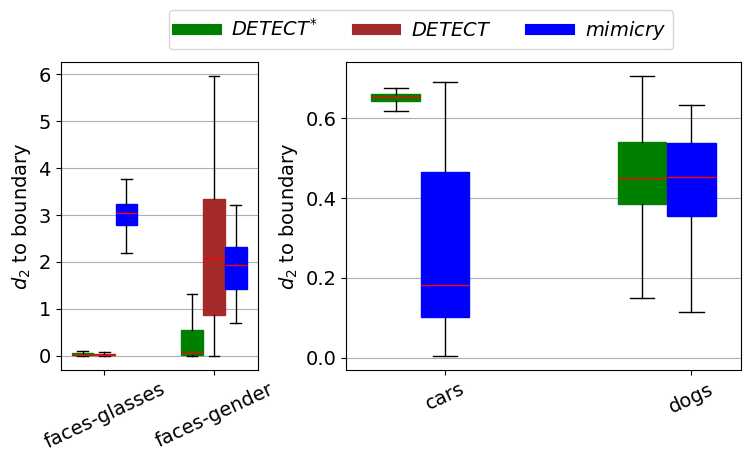

In [43]:
colors = ["green", "brown", "blue"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={"width_ratios": [1, 2]})

plot_on_axis(
    [df["boundary_distance"], df_male["boundary_distance"]],
    [glasses_relevant_df["boundary_distance"], male_relevant_df["boundary_distance"]],
    [mimicry_faces_data["boundary_distance"], mimicry_faces_data_male["boundary_distance"]],
    exp_labels=["$DETECT^{*}$", "$DETECT$", "$mimicry$"],
    tick_labels=["faces-glasses", "faces-gender"],
    name="$d_2$ to boundary",
    log=False,
    ax=ax1,
)

plot_on_axis(
    [cars_df["boundary_distance"], dogs_df["boundary_distance"]],
    [[], []],
    [mimicry_cars_data["boundary_distance"], mimicry_dogs_data["boundary_distance"]],
    exp_labels=["$DETECT^{*}$", "$DETECT$", "$mimicry$"],
    tick_labels=["cars", "dogs"],
    name="$d_2$ to boundary",
    log=False,
    ax=ax2,
)

ax1.legend(loc="upper left", bbox_to_anchor=(0.5, 1.20), ncol=3)
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.savefig("figures/RQ2/boundary_distance.pdf", bbox_inches="tight")

for df_list in [
    [
        df["boundary_distance"],
        df_male["boundary_distance"],
        cars_df["boundary_distance"],
        dogs_df["boundary_distance"],
    ],
    [glasses_relevant_df["boundary_distance"], male_relevant_df["boundary_distance"]],
    [
        mimicry_faces_data["boundary_distance"],
        mimicry_faces_data_male["boundary_distance"],
        mimicry_cars_data["boundary_distance"],
        mimicry_dogs_data["boundary_distance"],
    ],
]:
    print("=" * 40)
    for elem in df_list:
        print(f"Mean: {np.mean(elem):.3f}, Std: {np.std(elem):.3f}")

### Statistical stuff

In [59]:
from scipy.stats import norm


def run_statistical_tests(df1, df2, keys_alt: dict[str, str]) -> None:
    print("Stats: ")
    for key, alt in keys_alt.items():
        _, pval = mannwhitneyu(df1[key], df2[key], alternative=alt)
        d = cohens_d(df1[key].tolist(), df2[key].tolist())
        print(
            f"\t{key} Mann-Whitney U test: p-value = {pval:.2e}, Cohens-D: {d:.2f}, Sigma: {norm.isf(np.clip(pval, 1e-300, 1 - 1e-16)):.2f}"
        )

In [60]:
keys = {
    "distance": "less",
    "ssim": "greater",
    "runtime": "less",
    "change": "greater",
    "boundary_distance": "less",
}
for d in [
    df,
    df_male,
    cars_df,
    dogs_df,
    mimicry_faces_data_male,
    mimicry_faces_data,
    mimicry_cars_data,
    mimicry_dogs_data,
]:
    for k in keys.keys():
        d[k] = d[k].apply(
            lambda x: complex(x).real if isinstance(x, str) or isinstance(x, complex) else float(x)
        )

In [61]:
run_statistical_tests(df, mimicry_faces_data, keys_alt=keys)
run_statistical_tests(df_male, mimicry_faces_data_male, keys_alt=keys)
run_statistical_tests(cars_df, mimicry_cars_data, keys_alt=keys)
run_statistical_tests(dogs_df, mimicry_dogs_data, keys_alt=keys)

Stats: 
	distance Mann-Whitney U test: p-value = 5.75e-15, Cohens-D: 3.52, Sigma: 7.72
	ssim Mann-Whitney U test: p-value = 4.86e-16, Cohens-D: 4.86, Sigma: 8.03
	runtime Mann-Whitney U test: p-value = 3.46e-16, Cohens-D: 160.22, Sigma: 8.07
	change Mann-Whitney U test: p-value = 2.79e-15, Cohens-D: 2.72, Sigma: 7.81
	boundary_distance Mann-Whitney U test: p-value = 3.46e-16, Cohens-D: 9.10, Sigma: 8.07
Stats: 
	distance Mann-Whitney U test: p-value = 5.59e-25, Cohens-D: 1.98, Sigma: 10.26
	ssim Mann-Whitney U test: p-value = 6.48e-32, Cohens-D: 3.90, Sigma: 11.70
	runtime Mann-Whitney U test: p-value = 1.79e-33, Cohens-D: 44.95, Sigma: 12.00
	change Mann-Whitney U test: p-value = 3.55e-16, Cohens-D: 1.12, Sigma: 8.07
	boundary_distance Mann-Whitney U test: p-value = 5.25e-21, Cohens-D: 1.45, Sigma: 9.33
Stats: 
	distance Mann-Whitney U test: p-value = 8.68e-29, Cohens-D: 3.50, Sigma: 11.07
	ssim Mann-Whitney U test: p-value = 1.52e-30, Cohens-D: 5.52, Sigma: 11.43
	runtime Mann-Whitne

In [64]:
for dd in [dogs_df, cars_df]:
    print("escape_ratio: ", dd["escaped"].mean())

for md in [mimicry_dogs_data, mimicry_cars_data]:
    print("escape_ratio: ", md["escaped"].mean())

escape_ratio:  0.2396039603960396
escape_ratio:  0.0
escape_ratio:  0.22
escape_ratio:  0.0


### Image Comparison

In [7]:
import random

n = 3


def get_matched_rows(df1, df2, seed_column="seed", n=3, seed=None):
    shared_seeds = list(set(df1[seed_column]) & set(df2[seed_column]))
    random.seed(seed)
    sampled_seeds = random.sample(shared_seeds, n)

    df1_filtered = df1[df1[seed_column].isin(sampled_seeds)].drop_duplicates(subset=seed_column)
    df2_filtered = df2[df2[seed_column].isin(sampled_seeds)].drop_duplicates(subset=seed_column)

    df1_filtered = df1_filtered.sort_values(seed_column).reset_index(drop=True)
    df2_filtered = df2_filtered.sort_values(seed_column).reset_index(drop=True)
    return df1_filtered, df2_filtered


sample_glasses_relevant, sample_mimicry_glasses = get_matched_rows(
    glasses_relevant_df, mimicry_faces_data, n=n, seed=5
)
sample_male_relevant, sample_mimicry_male = get_matched_rows(
    male_relevant_df, mimicry_faces_data_male, n=n, seed=1
)
sample_cars_relevant, sample_mimicry_cars = get_matched_rows(
    cars_df, mimicry_cars_data, n=n, seed=5
)
sample_dogs_relevant, sample_mimicry_dogs = get_matched_rows(
    dogs_df, mimicry_dogs_data, n=n, seed=4
)


def get_orig_path(p):
    return "/".join(p.split("/")[:-1]) + "/1_original.png"


for df in [
    sample_glasses_relevant,
    sample_male_relevant,
    sample_cars_relevant,
    sample_dogs_relevant,
]:
    df["orig_path"] = df["img_path"].apply(get_orig_path)

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def plot_task_comparison(
    detect_orig_paths, detect_pert_paths, mimicry_orig_paths, mimicry_pert_paths, save_path=None
):
    num_pairs = len(detect_orig_paths)
    assert num_pairs == len(detect_pert_paths) == len(mimicry_orig_paths) == len(mimicry_pert_paths)

    tools = ["DETECT", "MIMICRY"]
    all_paths = [
        list(zip(detect_orig_paths, detect_pert_paths)),
        list(zip(mimicry_orig_paths, mimicry_pert_paths)),
    ]
    width_ratios = [0.025] + [1] * num_pairs
    fig, axes = plt.subplots(
        2,
        num_pairs + 1,
        figsize=(4 * (num_pairs + 1), 5),
        gridspec_kw={"width_ratios": width_ratios, "wspace": 0.1, "hspace": 0},
        constrained_layout=True,
    )

    # Left column: tool names (vertical text)
    for row in range(2):
        axes[row, 0].text(0.5, 0.5, tools[row], fontsize=22, va="center", ha="center", rotation=90)
        axes[row, 0].axis("off")

    for row in range(2):
        for i, (orig, pert) in enumerate(all_paths[row]):
            ax = axes[row, i + 1]

            im_orig = mpimg.imread(orig)
            im_pert = mpimg.imread(pert)

            combined = np.hstack((im_orig, im_pert))

            ax.imshow(combined)
            ax.axis("off")
            ax.set_aspect("equal")

    # Make vertical spacing tighter
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    else:
        plt.show()

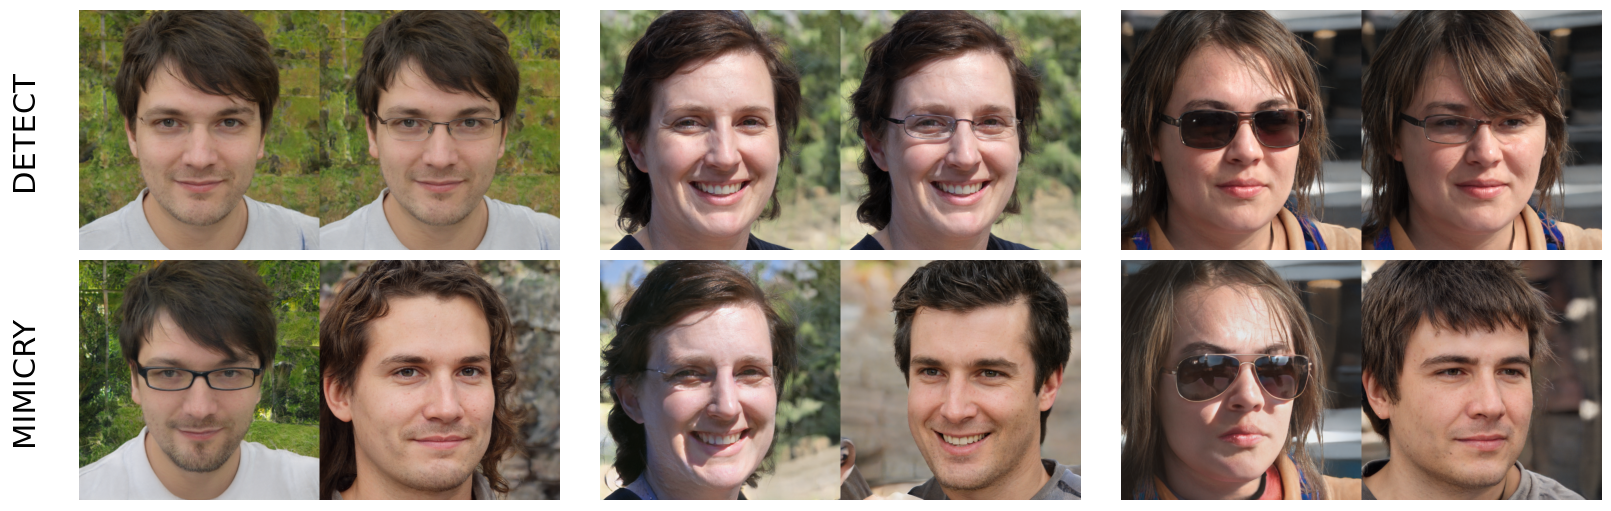

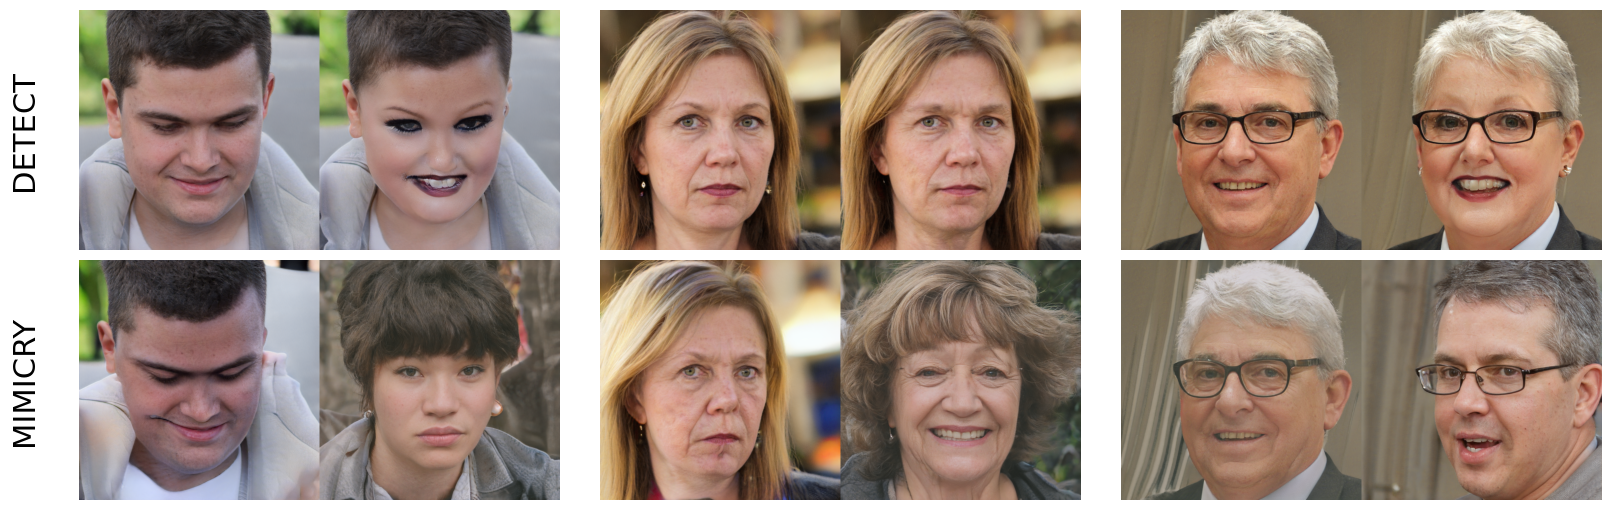

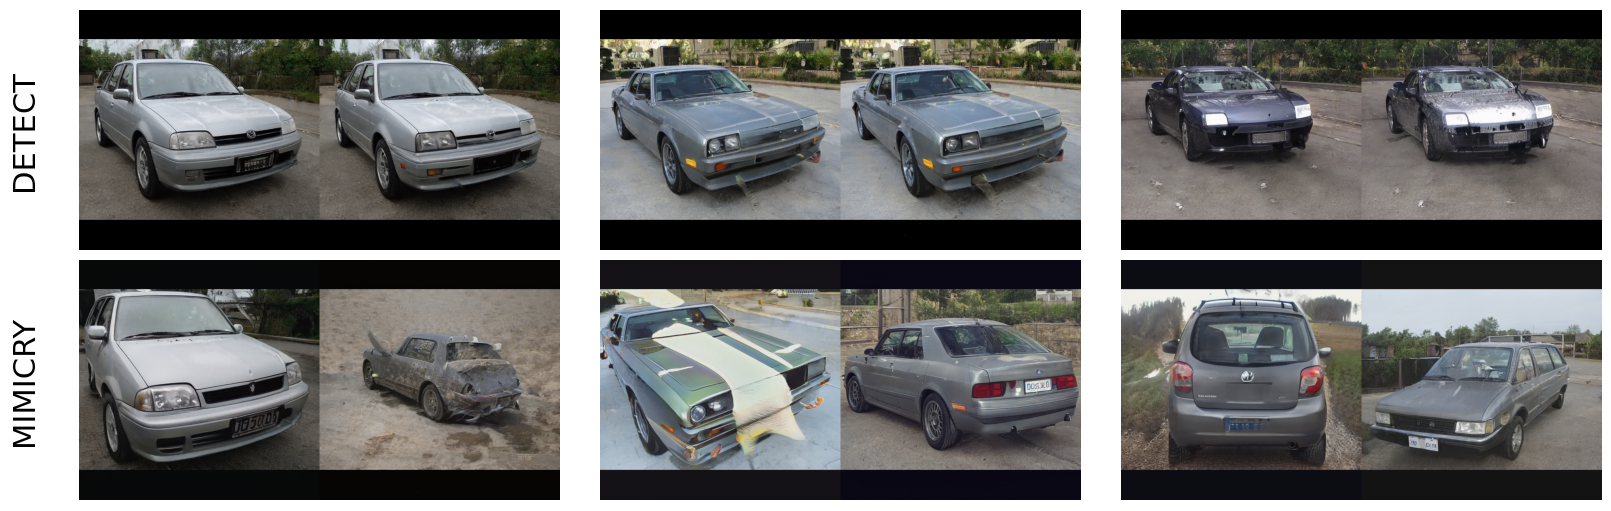

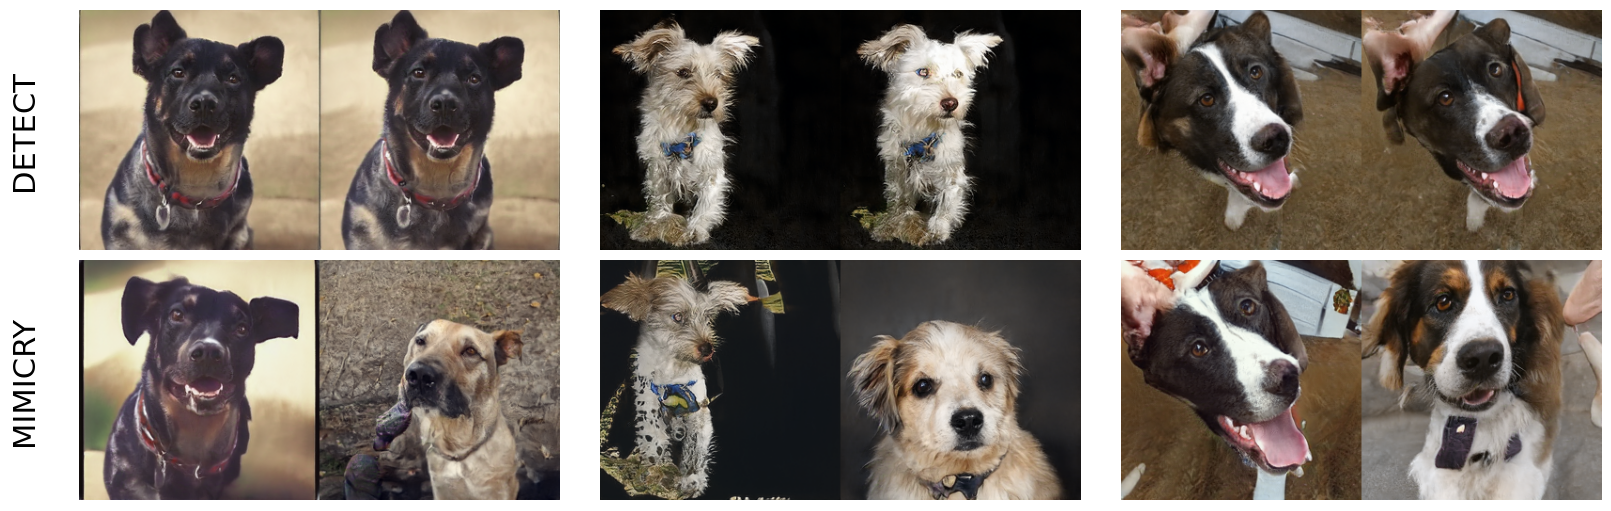

In [10]:
plot_task_comparison(
    detect_orig_paths=sample_glasses_relevant["orig_path"].tolist(),
    detect_pert_paths=sample_glasses_relevant["img_path"].tolist(),
    mimicry_orig_paths=sample_mimicry_glasses["origin_img"].tolist(),
    mimicry_pert_paths=sample_mimicry_glasses["best_img"].tolist(),
    save_path="figures/RQ2/faces_glasses.pdf",
)

plot_task_comparison(
    detect_orig_paths=sample_male_relevant["orig_path"].tolist(),
    detect_pert_paths=sample_male_relevant["img_path"].tolist(),
    mimicry_orig_paths=sample_mimicry_male["origin_img"].tolist(),
    mimicry_pert_paths=sample_mimicry_male["best_img"].tolist(),
    save_path="figures/RQ2/faces_gender.pdf",
)

plot_task_comparison(
    detect_orig_paths=sample_cars_relevant["orig_path"].tolist(),
    detect_pert_paths=sample_cars_relevant["img_path"].tolist(),
    mimicry_orig_paths=sample_mimicry_cars["origin_img"].tolist(),
    mimicry_pert_paths=sample_mimicry_cars["best_img"].tolist(),
    save_path="figures/RQ2/cars.pdf",
)

plot_task_comparison(
    detect_orig_paths=sample_dogs_relevant["orig_path"].tolist(),
    detect_pert_paths=sample_dogs_relevant["img_path"].tolist(),
    mimicry_orig_paths=sample_mimicry_dogs["origin_img"].tolist(),
    mimicry_pert_paths=sample_mimicry_dogs["best_img"].tolist(),
    save_path="figures/RQ2/dogs.pdf",
)